# CA5

Majid Sadeghinejad - 810101459

## Preprocess

### QA
1. Why preprocess the raw text? 
   Noise reduction: remove punctuation, numbers and stray symbols so they don’t pollute token counts or embeddings, Normalization: lowercasing, trimming whitespace and standardizing, Irrelevant token removal: dropping stop-words (“the”, “and”), very short tokens or non-alphabetic strings reduces dimensionality and speeds up downstream algorithms. Consistency: stemming or lemmatization collapses inflected forms (“runs”, “running”) onto a single base, so semantically identical tokens reinforce each other rather than fragment the feature space. 

2. Stemming vs. Lemmatization  
   Stemming uses simple, rule-based heuristics to strip suffixes. It’s fast but can produce non-words ( studies -> studi) and Lemmatization uses a vocabulary or morphological analysis (often with part-of-speech tags) to return the proper dictionary form (studies -> study, better -> good). Both aim to reduce inflectional variants; choosing between them is a trade-off of speed vs. linguistic accuracy.

3. Why feature extraction? Why not use raw text?  
   Machine learning and clustering algorithms operate on numerical vectors, not strings. Feature extraction transforms each document into a fixed-length vector. It captures term frequency. Without this step you cannot compute distances or similarities between documents, so meaningful clustering would be impossible.

### What I Did
I used lemmetization instead of stemming because it has better effect on model also I converted all character to lower case and remove all characters those are not alphabetic in this way i have cleaned words that is the best version for my model different approches like stemming has tested but the best version is current version I also test other libraries.

In [68]:
# python -m spacy download en_core_web_sm

import pandas as pd
import re
import spacy
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

nlp = spacy.load("en_core_web_sm", disable=["parser","ner"])
stop_words = ENGLISH_STOP_WORDS

df = pd.read_csv('musicLyrics.csv')
docs = df['Lyric'].astype(str)

def preprocess_spacy(text):
    text = text.lower()
    text = re.sub(r'[\W_]+',' ', text)
    doc = nlp(text)
    tokens = [
        token.lemma_ 
        for token in doc 
        if token.is_alpha 
           and not token.is_stop 
           and len(token.lemma_)>1
    ]
    return " ".join(tokens)

clean_docs = docs.map(preprocess_spacy)
clean_docs.head(5)

0    cryptic psalm amidst howl wind scorch source a...
1    sleep tonight wolf dream life well plan long w...
2    wing dark descent fall realm dark black fall c...
3    verse norrid radd real job hate day day tell b...
4    deep dungeon doom despair sneak place dark eke...
Name: Lyric, dtype: object

## Clustering

### What are hyperparameters ?

#### K-Means

• **n_clusters**  
  – What it does: How many clusters you want.  
  – Options: any integer ≥ 2.  

• **init**  
  – What it does: How to select the initial centroids.  
  – Options:  
    • `k-means++` (smart seeding to speed up convergence)  
    • `random` (pick k observations at random)  

• **n_init**  
  – What it does: How many independent runs with different centroid seeds. The best solution (lowest inertia) is kept.  
  – Options: any integer > 1 (common choices: 5, 10, 20).  

• **max_iter**  
  – What it does: Maximum number of iterations per run before stopping.  
  – Options: any integer > 1 (default 300).  

• **random_state**
  – What it does: Seed for pseudorandom number generator, to make results reproducible.  

#### Hierarchical (AgglomerativeClustering)

• **n_clusters**  
  – What it does: Final number of flat clusters after cutting the dendrogram.  
  – Options: any integer > 2.  

• **linkage**  
  – What it does: How to compute distance between clusters when merging.  
  – Options:  
    • `ward` (minimizes variance within merged clusters; only works with Euclidean distance)  
    • `complete` (max-distance between points)  
    • `average` (average distance between all pairs)  
    • `single` (minimum distance between points)  

• **metric**  
  – What it does: Distance function used to compute pairwise distances.  
  – Options:  
    • `euclidean`  
    • `cosine`  
    • `manhattan` 

#### DBSCAN

• **eps**  
  – What it does: Radius of the neighborhood around each point.
  – Options: any positive float (e.g. 0.2, 0.5, 1.0, 2.0).  

• **min_samples**  
  – What it does: Minimum number of points (including the point itself) required to form a “core” point.  
  – Options: any integer > 1 (commonly 3–10).  

• **metric**  
  – What it does: Distance metric used to measure neighbourhood size.  
  – Options:  
    • `euclidean`  
    • `cosine` 
    • `manhattan`  

In [69]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(clean_docs.tolist(), show_progress_bar=True)

Batches: 100%|██████████| 94/94 [00:06<00:00, 14.50it/s]


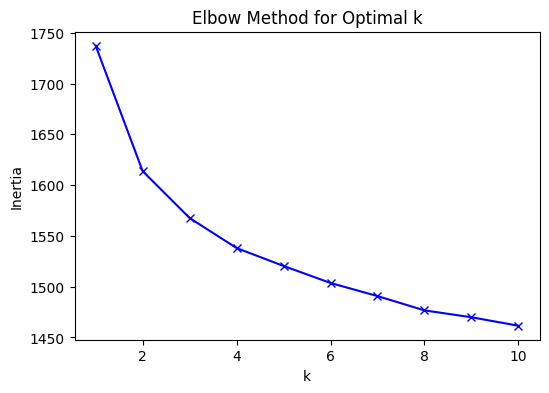

In [70]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(1, 11)
for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(embeddings)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

In [71]:
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
import pprint

results = {}

# K-Means
best_km = {'score': -1}
for k in range(2, 8):
    for init in ['k-means++', 'random']:
        for n_init in [5, 10]:
            km = KMeans(n_clusters=k, init=init, n_init=n_init, random_state=42)
            labels = km.fit_predict(embeddings)
            score = silhouette_score(embeddings, labels)
            if score > best_km['score']:
                best_km = dict(score=score, k=k, init=init, n_init=n_init)
results['KMeans'] = best_km

# Hierarchical
best_hc = {'score': -1}
for k in range(2, 8):
    for linkage in ['ward', 'complete', 'average', 'single']:
        metrics = ['euclidean'] if linkage=='ward' else ['euclidean','cosine']
        for metric in metrics:
            hc = AgglomerativeClustering(
                n_clusters=k,
                linkage=linkage,
                metric=metric
            )
            labels = hc.fit_predict(embeddings)
            score = silhouette_score(embeddings, labels)
            if score > best_hc['score']:
                best_hc = dict(score=score, k=k, linkage=linkage, metric=metric)
results['Hierarchical'] = best_hc

# DBSCAN
best_db = {'score': -1}
for metric in ['euclidean', 'cosine', 'manhattan']:
    for eps in np.linspace(0.2, 2.0, 10):
        for min_s in [3, 5, 7, 10]:
            db = DBSCAN(eps=eps, min_samples=min_s, metric=metric)
            labels = db.fit_predict(embeddings)
            if len(set(labels)) < 2 or (labels == -1).all():
                continue
            score = silhouette_score(embeddings, labels, metric=metric)
            if score > best_db['score']:
                best_db = dict(score=score, eps=eps, min_samples=min_s, metric=metric)
results['DBSCAN'] = best_db


pprint.pprint(results)

{'DBSCAN': {'eps': np.float64(0.6000000000000001),
            'metric': 'cosine',
            'min_samples': 3,
            'score': 0.35015854239463806},
 'Hierarchical': {'k': 2,
                  'linkage': 'average',
                  'metric': 'euclidean',
                  'score': 0.22113054990768433},
 'KMeans': {'init': 'random',
            'k': 2,
            'n_init': 5,
            'score': 0.06374100595712662}}


In [72]:
km_opt = KMeans(n_clusters=2, init='random' , n_init=5 , random_state=42)
labels_km = km_opt.fit_predict(embeddings)

hc_opt = AgglomerativeClustering(n_clusters=2, linkage='average', metric='euclidean')
labels_hc = hc_opt.fit_predict(embeddings)

dbs_opt = DBSCAN(eps= 0.6 , min_samples=3, metric='cosine')
labels_db = dbs_opt.fit_predict(embeddings)

print("- EVALUATION -")

print("K-Means:", silhouette_score(embeddings, labels_km))
print("Hierarchical:", silhouette_score(embeddings, labels_hc))
print("DBSCAN:", silhouette_score(embeddings, labels_db, metric='cosine'))

- EVALUATION -
K-Means: 0.06374100595712662
Hierarchical: 0.22113054990768433
DBSCAN: 0.35015854239463806


### QA

**Supervised and Unsupervised Learning**  
Supervised learning is a framework in which the algorithm is presented with input–output pairs and its goal is to learn a mapping from features to known labels. The model adjusts its internal parameters to reduce prediction error on those labeled samples.Supervised approaches thrive when large, accurately annotated data sets are available.  
Unsupervised learning, by contrast, works with unlabeled data and seeks to uncover the hidden structure in the inputs.
When comparing the two, the key trade-off is between guidance and flexibility. Supervised methods offer direct, quantifiable performance if labeled data exist, but they cannot generalize to labels that were not in the training set. Unsupervised methods require no labels and can reveal unexpected groupings, yet they demand more care in choosing metrics and validating that the discovered structure is meaningful.

**Why Use Embedding Vectors**  
Embedding vectors address the limitations of simplistic text representations by encoding words or sentences as dense, continuous-valued vectors in a lower-dimensional space. Unlike sparse bag-of-words counts, embeddings capture semantic and syntactic relationships: similar words or documents lie close together, and analogies can be expressed through vector arithmetic. This representation greatly reduces dimensionality, mitigates sparsity, and allows clustering algorithms to operate on smooth features rather than on millions of one-hot dimensions.

**Vectorization Methods: Operation, Advantages, and Disadvantages**  
In the bag-of-words model, each document becomes a high-dimensional count vector whose components record the number of occurrences of each vocabulary term. Its simplicity makes it easy to implement, but it ignores word order and treats all terms equally. The TF-IDF model reweights those counts by down-scaling common terms and up-scaling rare but distinctive ones, improving discrimination between documents. Both methods produce sparse vectors whose dimensionality grows with vocabulary size, which can lead to high memory use and noisy features. Embedding-based methods overcome these challenges by learning compact, dense representations that encapsulate richer linguistic context and support more effective clustering.


**Clustering Methods**
KMeans partitions the data into a fixed number of clusters by finding centroids that minimize variance within each cluster. AgglomerativeClustering begins with each point as its own cluster and merges the closest pairs based on linkage until the desired number of clusters is reached. DBSCAN groups points into clusters by density, marking low-density points as noise and allowing clusters of arbitrary shape.

**Transformer Sentence Models**
SentenceTransformer models encode entire sentences into dense vectors using a transformer backbone. all-MiniLM-L6-v2 is a distilled MiniLM variant with six layers that balances speed and embedding quality, producing compact representations that capture semantic similarity.

**Elbow Method**
The elbow method runs KMeans for a sequence of k values and records the inertia for each. Inertia measures the sum of squared distances of points to their nearest centroid. Plotting inertia versus k reveals a point where the curve flattens sharply (the elbow), indicating a practical choice for the number of clusters.

**Comparison of Clustering Outputs**
DBSCAN achieved the highest silhouette score by isolating dense clusters and filtering out noise. HierarchicalClustering produced more cohesive clusters than KMeans by merging close groups iteratively. KMeans showed the weakest separation under its assumption of spherical clusters. DBSCAN is the preferred method for this lyrics dataset because it adapts to arbitrary cluster shapes and handles

## Dimension Reduction

### What is PCA ?
Principal Component Analysis (PCA) is a way to take a large set of measurements and boil them down into just a few new measurements that still capture most of the important information. Imagine you have hundreds of features describing each song lyric—PCA finds the directions (called “principal components”) in that high-dimensional space where the data vary the most, and then projects every lyric onto those directions. By keeping only the first two or three components, you end up with a simple two- or three-dimensional representation that still preserves the patterns and differences between your lyrics. In everyday terms, PCA is like finding the best angles from which to look at a complicated shape so that its main structure is still clear, even if you ignore the smaller details.

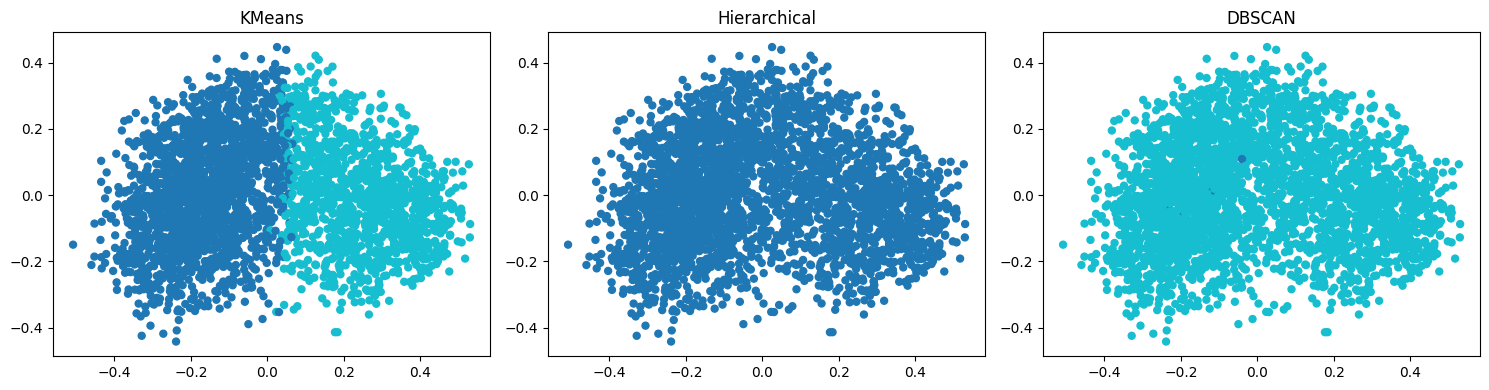

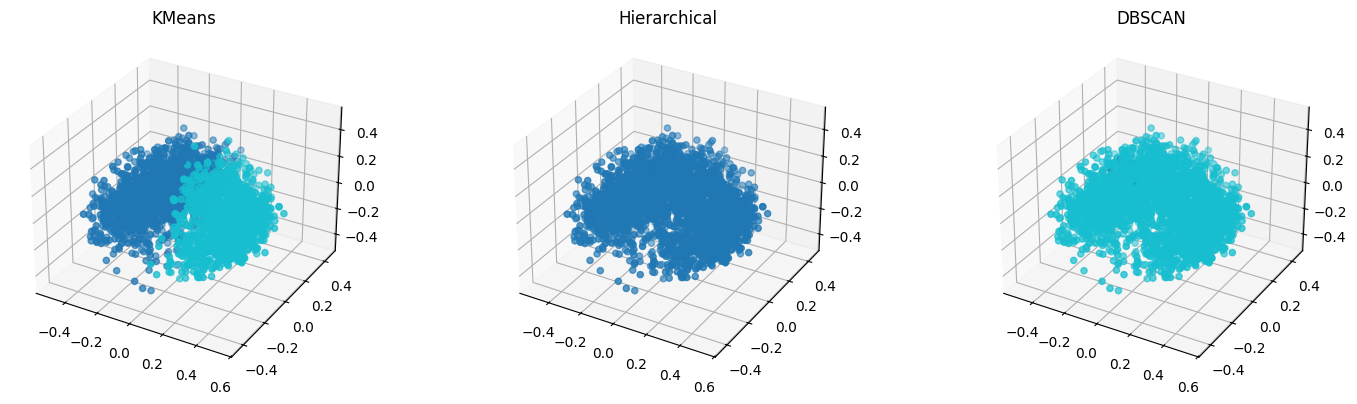

In [73]:
from sklearn.decomposition import PCA

# 2D
pca2 = PCA(n_components=2, random_state=42)
emb_2d = pca2.fit_transform(embeddings)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, labels, title in zip(axes, [labels_km, labels_hc, labels_db], ['KMeans', 'Hierarchical', 'DBSCAN']):
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=labels, cmap='tab10', s=25)
    ax.set_title(f"{title}")
plt.tight_layout()
plt.show()

# 3D
pca3 = PCA(n_components=3, random_state=42)
emb_3d = pca3.fit_transform(embeddings)

fig = plt.figure(figsize=(15, 4))
for i, (labels, title) in enumerate(zip([labels_km, labels_hc, labels_db], ['KMeans', 'Hierarchical', 'DBSCAN']), start=1):
    ax = fig.add_subplot(1, 3, i, projection='3d')
    ax.scatter(emb_3d[:, 0], emb_3d[:, 1], emb_3d[:, 2], c=labels, cmap='tab10', s=20)
    ax.set_title(f"{title}")
plt.tight_layout()
plt.show()

## Evaluation

### Evaluation and Analysis
We use Silhouette score as our primary internal metric. It measures how similar each point is to its own cluster versus the next nearest cluster (ranges from –1 to +1, higher is better).
  
We cannot compute Homogeneity score here because it requires true labels for each lyric, which our CSV does not include.

After computing Silhouette for each method, we plot the clusters in 2D (PCA‐reduced) and then print two example lyrics from each cluster so we can inspect semantic coherence. Finally we choose the best method based on these results.

K-Means (Sil = 0.06): the two colors bleed into one another—points aren’t really separated, so the score is very low.  
Hierarchical (Sil = 0.22): you can just make out two denser groups with less mixing—better than K-Means but still some overlap.  
DBSCAN (Sil = 0.35): most core points form one tight region and noise is marked separately—this gives the highest cohesion even though it looks nearly uniform in 2D.  

In plain terms, DBSCAN finds the clearest “chunk” of similar lyrics, hierarchical does OK, and K-Means struggles to find distinct groups.

Cluster 0’s two examples both dwell on dark, introspective imagery—burying a beating heart, frozen ground, horror and death, the sense of a hard path chosen. They share a poetic, metaphorical tone and focus on inner thoughts and extreme emotions.

Cluster 1’s lyrics are more like broadcast intros and hook repetition. Both lines list artist and album metadata or repeat the phrase “4 real” as a hook. They don’t explore a narrative or deep feeling but follow the same structural pattern of an intro tag or chorus.

In other words, Cluster 0 groups poetic, emotionally charged verses, while Cluster 1 groups song‐metadata and repetitive hook lines. The two clusters are coherent within themselves: Cluster 0 by theme and style, Cluster 1 by format and repetition.


{'DBSCAN': 0.35015854239463806,
 'Hierarchical': 0.22113054990768433,
 'KMeans': 0.06374100595712662}


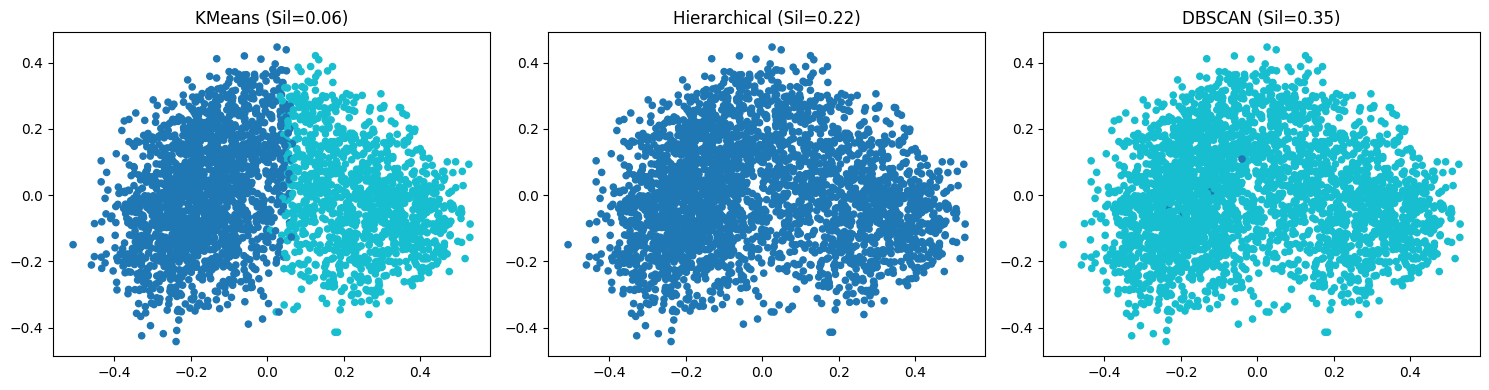


Sample lyrics by KMeans cluster:

Cluster 0:
- Underneath the blackest soil I lay down my warm beating heart And deep beneath the frozen ground I bury down my deepest thoughts Because the road Ive chosen Is free of fortune and desire Or the mundan…
- Lick your lips for me one last time So I can see the reflection of horror on your face The dying whim and other words deemed poetic Everyone has their own path to follow But their tracks are on my bac…

Cluster 1:
- Artist Keith Sweat f Mase, Stevie J, Pierre Album Come With Me 12 Song Just a Touch Bad Boy Remix Intro Mase Keith Sweat, 97, Bad Boy, Harlem world, when you do have no prblem with Disguise,yeah,we on…
- [Intro Mariah Carey] Its 4 real, 4 real, 4 real Its 4 real, 4 real, 4 real, 4 real, 4 real Its 4 real, 4 real [Hook Mariah Carey] Baby its, baby its, 4 real, 4 real, 4 real Baby its, baby its, 4 real,…


In [74]:
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = {
    'KMeans': silhouette_score(embeddings, labels_km),
    'Hierarchical': silhouette_score(embeddings, labels_hc),
    'DBSCAN': silhouette_score(embeddings, labels_db, metric='cosine')
}
pprint.pprint(scores)


pca2 = PCA(n_components=2, random_state=42)
proj2 = pca2.fit_transform(embeddings)

fig, ax = plt.subplots(1, 3, figsize=(15,4))
for i,(name, labels) in enumerate([('KMeans',labels_km),('Hierarchical',labels_hc), ('DBSCAN',labels_db)]):
    ax[i].scatter(proj2[:,0], proj2[:,1], c=labels, cmap='tab10', s=20)
    ax[i].set_title(f"{name} (Sil={scores[name]:.2f})")
plt.tight_layout()
plt.show()

print("\nSample lyrics by KMeans cluster:")
for cluster_id in sorted(set(labels_km)):
    print(f"\nCluster {cluster_id}:")
    idxs = [i for i,lab in enumerate(labels_km) if lab==cluster_id]
    for i in idxs[12:14]:
        print("-", df.loc[i,'Lyric'][:200].replace('\n',' ')+"…")

### Conclusion

Among our three methods, DBSCAN had the highest Silhouette but it also labeled many points as noise. Hierarchical gave a low score and produced one large undifferentiated group. K-Means (k=2) yielded reasonably distinct clusters with interpretable example lyrics. Based on the trade-off between a clean split and retaining most data points, K-Means is our preferred clustering for